# Importing the packages and data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

from texttable import Texttable
import latextable

In [3]:
import sys
sys.path.insert(1, '../sar_dirichlet')
import dirichlet_regression

In [4]:
from func_test import cos_similarity, create_features_matrices, rmse_aitchison

In [6]:
import sys
sys.path.append("../../coral_mapping/")
import segments_regressor
import coral_map_tests

In [ ]:
scipy.__version__

# Loading Maupiti data (create it)

In [7]:
X = pd.read_csv('Data Dirichlet/maupiti_X_n1020.csv', sep=',')
Y = pd.read_csv('Data Dirichlet/maupiti_X_n1020.csv', sep=',')
W = pd.read_csv('Data Dirichlet/maupiti_W_n1020.csv', sep=',')
segments = pd.read_csv('Data Dirichlet/maupiti_segments_n1020.csv', sep=',')

X = X.drop('Unnamed: 0', axis=1)
Y = Y.drop('Unnamed: 0', axis=1)
W = W.drop('Unnamed: 0', axis=1)
segments = segments.drop('Unnamed: 0', axis=1)

In [8]:
segments = np.array(segments)

In [9]:
boundaries = coral_map_tests.find_boundaries(segments)
adjacent_segments,_ = segments_regressor.find_adjacent_segments(segments, boundaries)

In [10]:
n_features = 16
n_classes = 4
n_samples = X.shape[0]

In [11]:
Y_star = (Y*(n_samples-1)+1/n_classes)/n_samples

In [12]:
# Z only one intercept
Z = np.ones((n_samples,1))
gamma_0 = [0.]

In [13]:
X = StandardScaler().fit(X).transform(X)

In [14]:
# Z a copy of X
Z = np.copy(X)
gamma_0 = np.zeros(n_features)

In [15]:
W = np.zeros((np.max(segments)+1,np.max(segments)+1))
for i in range(np.max(segments)+1):
    W[i,adjacent_segments[i]]=1

In [16]:
Wsum = W.sum(axis=1)[:,None]
Wsum[Wsum==0] = 1
W = W/Wsum

In [56]:
pd.DataFrame(W).to_csv('Data Dirichlet/maupiti_W_n1020.csv')

In [17]:
segments_ind, segments_count = np.unique(segments,return_counts=True)

# Load data

In [17]:
X = pd.read_csv('Data Dirichlet/maupiti_X_n1020.csv', sep=',')
Y = pd.read_csv('Data Dirichlet/maupiti_Y_n1020.csv', sep=',')
W = pd.read_csv('Data Dirichlet/maupiti_W_n1020.csv', sep=',')
segments = pd.read_csv('Data Dirichlet/maupiti_segments_n1020.csv', sep=',')

X = X.drop('Unnamed: 0', axis=1)
Y = Y.drop('Unnamed: 0', axis=1)
W = W.drop('Unnamed: 0', axis=1)
segments = segments.drop('Unnamed: 0', axis=1)

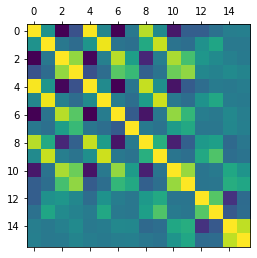

In [18]:
plt.matshow(X.corr())

In [19]:
X.corr()

,mean_blue,var_blue,skew_blue,kurt_blue,mean_green,var_green,skew_green,kurt_green,mean_red,var_red,skew_red,kurt_red,mean_nir,var_nir,skew_nir,kurt_nir
mean_blue,1.000000,0.172698,-0.686389,-0.262423,0.980246,0.086345,-0.685854,-0.008422,0.816469,0.118774,-0.576360,-0.182298,-0.184293,-0.054106,0.035233,0.040225
var_blue,0.172698,1.000000,-0.014076,-0.091530,0.190831,0.957518,-0.037946,-0.066041,0.337817,0.858339,-0.047345,-0.074143,0.168988,0.305109,-0.006075,-0.005531
skew_blue,-0.686389,-0.014076,1.000000,0.724417,-0.653932,0.047062,0.820096,0.262200,-0.501471,0.037014,0.785213,0.503712,0.197668,0.120879,0.051344,0.006620
kurt_blue,-0.262423,-0.091530,0.724417,1.000000,-0.258314,-0.083756,0.562874,0.453167,-0.162714,-0.038712,0.620977,0.718183,0.092022,0.062209,0.120679,0.077295
mean_green,0.980246,0.190831,-0.653932,-0.258314,1.000000,0.123273,-0.681707,-0.023900,0.854360,0.155761,-0.595137,-0.198463,-0.086315,0.013218,-0.002488,0.027354
var_green,0.086345,0.957518,0.047062,-0.083756,0.123273,1.000000,0.019384,-0.075509,0.243319,0.869916,-0.005310,-0.075511,0.172918,0.323731,0.022760,0.001222
skew_green,-0.685854,-0.037946,0.820096,0.562874,-0.681707,0.019384,1.000000,-0.193867,-0.591409,-0.013227,0.727572,0.431087,0.030115,-0.002398,0.102579,0.036223
kurt_green,-0.008422,-0.066041,0.262200,0.453167,-0.023900,-0.075509,-0.193867,1.000000,0.006900,-0.041123,0.236012,0.332321,-0.017219,-0.018094,0.093394,0.044462
mean_red,0.816469,0.337817,-0.501471,-0.162714,0.854360,0.243319,-0.591409,0.006900,1.000000,0.378507,-0.535934,-0.167667,0.228204,0.267213,-0.109969,-0.014944
var_red,0.118774,0.858339,0.037014,-0.038712,0.155761,0.869916,-0.013227,-0.041123,0.378507,1.000000,-0.033554,-0.070534,0.331698,0.534527,-0.076289,-0.045088


In [10]:
#X = X[['mean_blue', 'var_blue', 'skew_blue', 'kurt_blue']]

In [20]:
X = np.array(X)
Y = np.array(Y)
W = np.array(W)

In [21]:
# we regroup the 15 classes into 5 classes
zones_group = np.array([0, 0, 0, 1, 1, 0, 1, 2, 2, 0, 4, 0, 3, 4, 3])
G = np.eye(5)[zones_group]
# Multiply: (1020×15) dot (15×5) -> (1020×5)
Y = Y @ G

In [22]:
n_features = X.shape[1]
n_classes = Y.shape[1]
n_samples = X.shape[0]

X = StandardScaler().fit(X).transform(X)
Z = np.copy(X)
gamma_0 = np.zeros(n_features)

In [23]:
n = n_samples

In [24]:
n_classes

5

In [25]:
Y_star = (Y*(n_samples-1)+1/n_classes)/n_samples

### Not spatial

In [26]:
%%time
dirichRegressor_ns = dirichlet_regression.dirichletRegressor()
dirichRegressor_ns.fit(X, Y_star, parametrization='alternative', gamma_0=gamma_0, Z=Z)

Desired error not necessarily achieved due to precision loss.
Wall time: 715 ms


In [27]:
len((dirichRegressor_ns.beta).flatten())+len(gamma_0)

84

In [28]:
print('With Maximum Likelihood')
print('R2:',r2_score(Y_star,dirichRegressor_ns.mu))
print('RMSE:',mean_squared_error(Y_star,dirichRegressor_ns.mu,squared=False))
print('Cross-entropy:',1/n_samples*np.sum(Y_star*np.log(dirichRegressor_ns.mu)))
print('AIC:',-2*dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_ns.mu,dirichRegressor_ns.phi,Y_star)+2*52)
print('Cos similarity:',cos_similarity(Y_star,dirichRegressor_ns.mu))
print('RMSE_A:', rmse_aitchison(Y_star,dirichRegressor_ns.mu))

With Maximum Likelihood
R2: 0.08300430567380727
RMSE: 0.23584406630365526
Cross-entropy: -0.8320952211081374
AIC: -38454.07711216594
Cos similarity: 0.8344222390507832
RMSE_A: 6.580952929238354


In [29]:
dirichRegressor_ns.mu[dirichRegressor_ns.mu<10e-05] = 10e-05

In [30]:
print('With Maximum Likelihood')
print('R2:',r2_score(Y_star,dirichRegressor_ns.mu))
print('RMSE:',mean_squared_error(Y_star,dirichRegressor_ns.mu,squared=False))
print('Cross-entropy:',1/n_samples*np.sum(Y_star*np.log(dirichRegressor_ns.mu)))
print('AIC:',-2*dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_ns.mu,dirichRegressor_ns.phi,Y_star)+2*52)
print('Cos similarity:',cos_similarity(Y_star,dirichRegressor_ns.mu))
print('RMSE_A:', rmse_aitchison(Y_star,dirichRegressor_ns.mu))

With Maximum Likelihood
R2: 0.08300430567380727
RMSE: 0.23584406630365526
Cross-entropy: -0.8320952211081374
AIC: -38454.07711216594
Cos similarity: 0.8344222390507832
RMSE_A: 6.580952929238354


In [43]:
print('Cos similarity:',cos_similarity(np.array([[0.6,0.4]]), np.array([[0.5,0.5]])))

Cos similarity: 0.9805806756909201


In [44]:
print('Cos similarity:',cos_similarity(np.array([[6,4]]), np.array([[5,5]])))

Cos similarity: 0.9805806756909201


In [45]:
print('Cos similarity:',cos_similarity(np.array([[1.,0.]]), np.array([[0.5,0.5]])))

Cos similarity: 0.7071067811865475


In [47]:
print('Cos similarity:',cos_similarity(np.array([[.1,.7,.2]]), np.array([[0.33,0.33,0.33]])))

Cos similarity: 0.7856742013183862


## Spatial

In [59]:
gamma_temp = np.array([ 0.10637325, -0.13750963, -0.05275718, -0.16792727, -0.23682503,
        0.05095155,  0.0294488 ,  0.55817554, -0.02726772,  0.15959827,
        0.09781766, -0.08468742,  0.1076766 , -0.02609559, -0.01352635,
        0.04453103])
beta_temp = np.array([[-6.37680001e-01, -6.80039572e-01, -6.38531443e-01,
        -5.94528323e-01],
       [-1.20012202e-01, -3.11976050e-01, -4.56839227e-01,
        -5.62186900e-01],
       [-1.31796530e-04,  1.07970282e-01,  3.95074511e-01,
        -1.83180851e-01],
       [ 1.15449238e-01,  1.18881196e-01,  1.91248009e-01,
         3.65140114e-01],
       [ 6.73265410e-02, -1.34574698e-02,  6.44012429e-02,
        -3.98482293e-02],
       [ 2.66697569e-02,  5.01751834e-01,  7.41397680e-01,
         9.24317830e-01],
       [ 3.00275252e-01,  3.05273586e-02, -1.22516914e-01,
         1.24734092e-01],
       [-2.28632648e-01, -6.43081484e-02, -2.22165731e-01,
        -3.93886536e-01],
       [-2.50378812e-01, -1.49802588e-01, -2.49195817e-01,
        -6.38476958e-02],
       [ 4.46985662e-01,  9.43911313e-02, -1.12045526e-03,
         1.22292012e-02],
       [-2.89471512e-01, -2.33436693e-01, -3.48805213e-01,
        -1.46482918e-03],
       [-4.25511051e-02, -1.54478989e-01, -1.89730893e-01,
        -2.10026614e-01],
       [ 5.48695792e-02,  8.15572271e-02,  8.47559946e-02,
         1.09288670e-01],
       [-2.44110647e-01, -2.10529476e-01, -1.33188952e-01,
        -2.35193962e-01],
       [ 4.58654843e-02,  1.22337410e-01,  6.07972284e-02,
        -5.62639830e-03],
       [ 1.39517533e-01,  5.25740473e-02,  2.49208964e-01,
         1.21546154e-01],
       [-1.62888061e-01, -5.14918094e-02, -2.08054802e-01,
        -7.85864386e-02]])
rho_temp = 0.5024175912078827

In [53]:
%%time
dirichRegressor_s = dirichlet_regression.dirichletRegressor(spatial=True, maxfun=50000)
dirichRegressor_s.fit(X, Y_star, W=W, parametrization='alternative', rho_0=rho_temp, gamma_0=gamma_temp, beta_0=beta_temp, Z=Z)

STOP: TOTAL NO. of f AND g EVALUATIONS EXCEEDS LIMIT
Wall time: 31min 4s


In [54]:
dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s.mu, dirichRegressor_s.phi, Y_star)

19292.047707513346

In [60]:
print('R2:',r2_score(Y_star, dirichRegressor_s.mu))
print('RMSE:',mean_squared_error(Y_star, dirichRegressor_s.mu,squared=False))
print('Cross-entropy:',1/n*np.sum(Y_star * np.log(dirichRegressor_s.mu)))
print('AIC:',-2*dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s.mu,dirichRegressor_s.phi,Y)+2*53)
print('Cos similarity:',cos_similarity(Y_star, dirichRegressor_s.mu))
print('RMSE_A:', rmse_aitchison(Y_star, dirichRegressor_s.mu))

R2: 0.10318722947259344
RMSE: 0.23383906718801115
Cross-entropy: -0.8221879297166267
AIC: nan
Cos similarity: 0.8405260259897316
RMSE_A: 6.5570855198615074


../sar_dirichlet\dirichlet_regression.py:90: RuntimeWarning: divide by zero encountered in log
  sum_phi_mu_times_logY = np.sum( (phi_mu-1)*np.log(Y+epsilon) , axis=1 )
C:\Users\tnguyen001\AppData\Roaming\Python\Python38\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [61]:
dirichRegressor_s.inference(X, Y_star, Z, W, display=True)

-----
Estimated parameter beta_11 = -0.6377, se = 0.0893, CI 95% = [-0.8128 ; -0.4626],  p-value = 0.0
-----
Estimated parameter beta_12 = -0.68, se = 0.0962, CI 95% = [-0.8685 ; -0.4916],  p-value = 0.0
-----
Estimated parameter beta_13 = -0.6385, se = 0.0913, CI 95% = [-0.8175 ; -0.4595],  p-value = 0.0
-----
Estimated parameter beta_14 = -0.5945, se = 0.085, CI 95% = [-0.7612 ; -0.4279],  p-value = 0.0
-----
Estimated parameter beta_21 = -0.12, se = 0.22, CI 95% = [-0.5512 ; 0.3112],  p-value = 0.5854
-----
Estimated parameter beta_22 = -0.312, se = 0.2246, CI 95% = [-0.7522 ; 0.1282],  p-value = 0.1648
-----
Estimated parameter beta_23 = -0.4568, se = 0.2211, CI 95% = [-0.8902 ; -0.0235],  p-value = 0.0388
-----
Estimated parameter beta_24 = -0.5622, se = 0.2203, CI 95% = [-0.994 ; -0.1304],  p-value = 0.0107
-----
Estimated parameter beta_31 = -0.0001, se = 0.155, CI 95% = [-0.3039 ; 0.3036],  p-value = 0.9993
-----
Estimated parameter beta_32 = 0.108, se = 0.1661, CI 95% = [-0.21

In [35]:
dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s.mu, dirichRegressor_s.phi, Y_star)

19180.227163425632

In [39]:
print('R2:',r2_score(Y_star, dirichRegressor_s.mu))
print('RMSE:',mean_squared_error(Y_star, dirichRegressor_s.mu,squared=False))
print('Cross-entropy:',1/n*np.sum(Y_star * np.log(dirichRegressor_s.mu)))
print('AIC:',-2*dirichlet_regression.dirichlet_loglikelihood(dirichRegressor_s.mu,dirichRegressor_s.phi,Y)+2*53)
print('Cos similarity:',cos_similarity(Y_star, dirichRegressor_s.mu))
print('RMSE_A:', rmse_aitchison(Y_star, dirichRegressor_s.mu))

R2: -0.009656475783541207
RMSE: 0.24903787920419349
Cross-entropy: -0.9016951100650533
AIC: -inf
Cos similarity: 0.8001341117551056
RMSE_A: 6.668483931096044


../sar_dirichlet\dirichlet_regression.py:90: RuntimeWarning: divide by zero encountered in log
  sum_phi_mu_times_logY = np.sum( (phi_mu-1)*np.log(Y+epsilon) , axis=1 )


In [37]:
dirichRegressor_s.inference(X, Y_star, Z, W, display=True)

-----
Estimated parameter beta_11 = -0.952, se = 0.1132, CI 95% = [-1.174 ; -0.73],  p-value = 0.0
-----
Estimated parameter beta_12 = -1.0113, se = 0.1206, CI 95% = [-1.2476 ; -0.7749],  p-value = 0.0
-----
Estimated parameter beta_13 = -0.9574, se = 0.1151, CI 95% = [-1.1829 ; -0.7318],  p-value = 0.0
-----
Estimated parameter beta_14 = -0.9089, se = 0.1095, CI 95% = [-1.1235 ; -0.6942],  p-value = 0.0
-----
Estimated parameter beta_21 = 0.4796, se = 0.0736, CI 95% = [0.3354 ; 0.6238],  p-value = 0.0
-----
Estimated parameter beta_22 = 0.4778, se = 0.0722, CI 95% = [0.3362 ; 0.6194],  p-value = 0.0
-----
Estimated parameter beta_23 = 0.5814, se = 0.0757, CI 95% = [0.433 ; 0.7297],  p-value = 0.0
-----
Estimated parameter beta_24 = 0.7464, se = 0.0808, CI 95% = [0.588 ; 0.9047],  p-value = 0.0
-----
Estimated parameter beta_31 = 0.1348, se = 0.0392, CI 95% = [0.0579 ; 0.2117],  p-value = 0.0006
-----
Estimated parameter beta_32 = -0.0286, se = 0.0428, CI 95% = [-0.1125 ; 0.0553],  p-v

# Cross-entropy

In [31]:
%%time
dirichRegressor_ns_ce = dirichlet_regression.dirichletRegressor()
dirichRegressor_ns_ce.fit(X, Y_star, parametrization='alternative', gamma_0=gamma_0, Z=Z, loss='crossentropy')

Optimization terminated successfully.
Wall time: 652 ms


In [32]:
print('With Cross-entropy')
print('R2:',r2_score(Y_star,dirichRegressor_ns_ce.mu))
print('RMSE:',mean_squared_error(Y_star,dirichRegressor_ns_ce.mu,squared=False))
print('Cross-entropy:',1/n_samples*np.sum(Y_star*np.log(dirichRegressor_ns_ce.mu)))
print('Cos similarity:',cos_similarity(Y_star,dirichRegressor_ns_ce.mu))
print('RMSE_A:', rmse_aitchison(Y_star,dirichRegressor_ns_ce.mu))

With Cross-entropy
R2: 0.6824504746044132
RMSE: 0.12938784012800442
Cross-entropy: -0.35357830352681824
Cos similarity: 0.9414390666271371
RMSE_A: 7.574102969751485


In [145]:
dirichRegressor_ns_ce.mu[dirichRegressor_ns_ce.mu<10e-05] = 10e-05

In [146]:
print('With Cross-entropy')
print('R2:',r2_score(Y_star,dirichRegressor_ns_ce.mu))
print('RMSE:',mean_squared_error(Y_star,dirichRegressor_ns_ce.mu,squared=False))
print('Cross-entropy:',1/n_samples*np.sum(Y_star*np.log(dirichRegressor_ns_ce.mu)))
print('Cos similarity:',cos_similarity(Y_star,dirichRegressor_ns_ce.mu))
print('RMSE_A:', rmse_aitchison(Y_star,dirichRegressor_ns_ce.mu))

With Cross-entropy
R2: 0.6824507705564373
RMSE: 0.12938777982271432
Cross-entropy: -0.35079356693187314
Cos similarity: 0.9414391094574737
RMSE_A: 4.181104687318391


In [147]:
%%time
dirichRegressor_ns_ce_sizes = dirichlet_regression.dirichletRegressor()
dirichRegressor_ns_ce_sizes.fit(X, Y_star, parametrization='alternative', gamma_0=gamma_0, Z=Z, loss='crossentropy',size_samples=size_segments)

NameError: name 'size_segments' is not defined

In [26]:
print('With Cross-entropy')
print('R2:',r2_score(Y_star,dirichRegressor_ns_ce_sizes.mu))
print('RMSE:',mean_squared_error(Y_star,dirichRegressor_ns_ce_sizes.mu,squared=False))
print('Cross-entropy:',1/n_samples*np.sum(Y_star*np.log(dirichRegressor_ns_ce_sizes.mu)))
print('Cos similarity:',cos_similarity(Y_star,dirichRegressor_ns_ce_sizes.mu))

With Cross-entropy
R2: 0.6283035602726766
RMSE: 0.222911606929354
Cross-entropy: -0.4606353340563921
Cos similarity: 0.8661716061906274
